# Новый алгоритм рекомендаций в развлекательном приложении: A/B-тест

Учебный проект программы «Аналитик данных» (Яндекс Практикум), выполнен самостоятельно.
Стек: Python, pandas, matplotlib, statsmodels.

## Цель и задачи

**Цель:** спланировать A/B-тест нового алгоритма рекомендаций и оценить его влияние на вовлечённость пользователей.

**Что сделано:**
1. Разведочный анализ исторических данных: регистрации, просмотры страниц, доля «успешных» первых сессий.
2. Расчёт размера выборки и длительности теста.
3. Проверка корректности разбиения на группы по данным первого дня теста.
4. Оценка результата теста z-тестом для долей и выводы для продуктовой команды.

## Данные

Учебный датасет Яндекс Практикума: логи сессий пользователей приложения. Данные являются материалами курса и в репозиторий не входят.

- исторические сессии (`sessions_project_history.csv`): август–сентябрь 2025 года, до теста;
- сессии первого дня теста (`sessions_project_test_part.csv`): 14.10.2025;
- сессии за весь период теста (`sessions_project_test.csv`): 14.10–02.11.2025.

Основные поля: пользователь, сессия, дата и время, дата установки, порядковый номер сессии, признак регистрации, число просмотренных страниц, регион, устройство и (в данных теста) группа A/B.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [1]:
import pandas as pd
sessions_history = pd.read_csv('data/sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными

In [2]:
users_sessions_counts = sessions_history.groupby('user_id')['session_id'].nunique() 

In [3]:
max_user_id = users_sessions_counts.idxmax()

In [4]:
sessions_history[sessions_history['user_id'] == max_user_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Пример одного пользователя (`10E0DEFC1ABDBBE0`) показывает логику данных:
- `install_date` одинакова во всех сессиях (2025-08-14), первая сессия прошла в день установки;
- `session_number` растёт с каждой сессией от 1 до 10;
- регион (CIS) и устройство (Android) не меняются, пользователь не зарегистрирован;
- `page_counter` от 1 до 4 страниц за сессию.

#### 1.3. Анализ числа регистраций

In [5]:
daily_users = sessions_history.groupby('session_date').agg(
total_users = ('user_id', 'nunique'),
registered_users = ('registration_flag', 'sum')).reset_index()

daily_users.head()

,session_date,total_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840


In [6]:
daily_users['registered_share'] = daily_users['registered_users'] / daily_users['total_users']

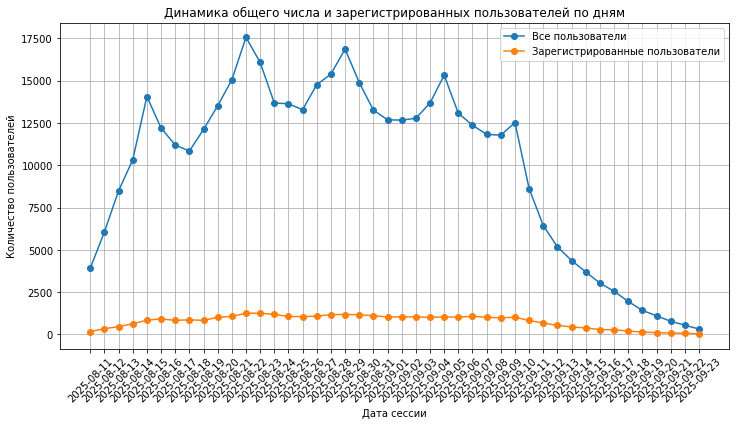

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_users['session_date'], daily_users['total_users'], label = 'Все пользователи', marker= 'o')
plt.plot(daily_users['session_date'], daily_users['registered_users'], label = 'Зарегистрированные пользователи', marker= 'o')

plt.title('Динамика общего числа и зарегистрированных пользователей по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

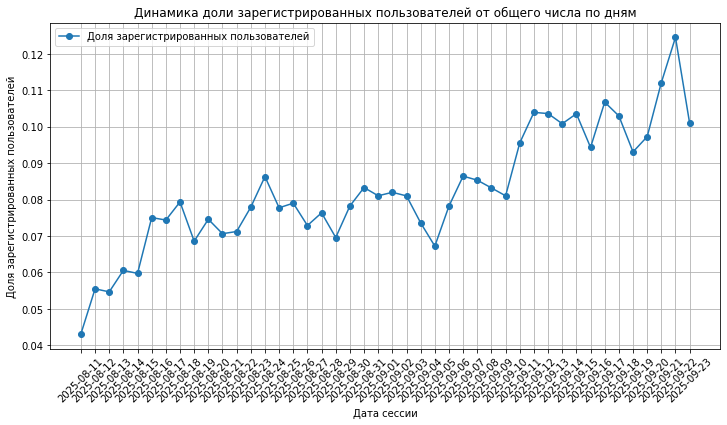

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(daily_users['session_date'], daily_users['registered_share'], label = 'Доля зарегистрированных пользователей', marker= 'o')

plt.title('Динамика доли зарегистрированных пользователей от общего числа по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Доля зарегистрированных пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

**Выводы по пользователям и регистрациям**

- Число пользователей в день росло с середины августа и достигло максимума 21 августа (около 17,5 тыс.); у графика выраженные колебания. С 10 сентября начинается резкое снижение трафика до нескольких сотен пользователей в день к 23 сентября.
- Число зарегистрированных пользователей в день держится около 1 тыс., максимум около 1,2 тыс.
- Доля зарегистрированных выросла с 4,3% в первый день до около 10% после 10 сентября; пик 12,5% (21 сентября) приходится на дни с очень малым общим трафиком, поэтому он неустойчив.

#### 1.4. Анализ числа просмотренных страниц

In [9]:
first_sessions = sessions_history[sessions_history['session_number'] == 1]
session_first_page = first_sessions['page_counter'].value_counts().sort_index().reset_index()

In [10]:
session_first_page.columns = ['page_counter', 'sessions_count']
session_first_page

,page_counter,sessions_count
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075
5,6,777
6,7,37


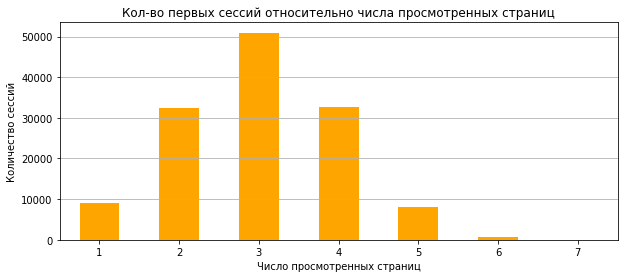

In [11]:
session_first_page.set_index('page_counter').plot(kind = 'bar', rot = 0, color = 'orange', legend=False, figsize=(10, 4))

plt.title('Кол-во первых сессий относительно числа просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(axis='y')

plt.show()

**Выводы по числу просмотренных страниц в первой сессии**

- Чаще всего в первой сессии просматривают 3 страницы: 50 939 сессий, около 38% всех первых сессий.
- Большинство первых сессий укладывается в 2–4 страницы; 5 и более страниц — менее 7% сессий, 1 страница — 8 978 сессий.

#### 1.5. Доля «успешных» первых сессий (4 и более страниц)

In [12]:
sessions_history['good_session'] = sessions_history['page_counter'] >= 4

In [13]:
first_sessions_daily = sessions_history[sessions_history['session_number'] == 1].groupby('session_date')['good_session'].mean().reset_index()
first_sessions_daily.columns = ['session_date', 'good_session_share']
first_sessions_daily.head()

,session_date,good_session_share
0,2025-08-11,0.312835
1,2025-08-12,0.298344
2,2025-08-13,0.306861
3,2025-08-14,0.319098
4,2025-08-15,0.311114


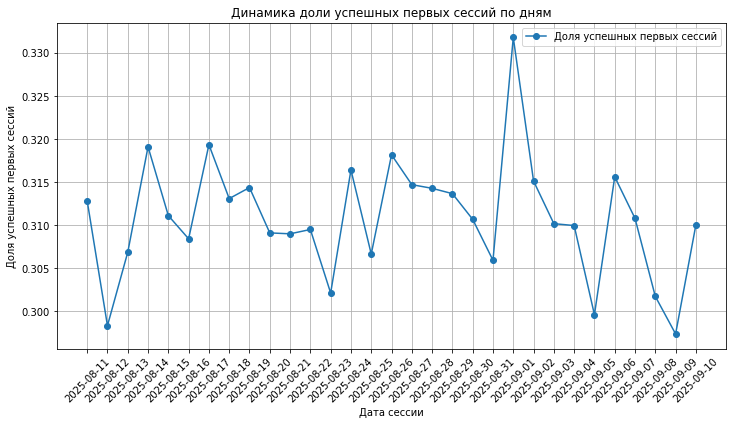

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(first_sessions_daily['session_date'], first_sessions_daily['good_session_share'], marker='o', label='Доля успешных первых сессий')
plt.title('Динамика доли успешных первых сессий по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Доля успешных первых сессий')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

**Выводы по доле успешных первых сессий**

- Доля первых сессий с 4 и более страницами стабильна: в среднем около 31%, по дням от ~29,7% до ~33,2%.
- Колебания по дням есть, поэтому тест лучше проводить полными неделями.

### 2. Подготовка к тесту

Целевая метрика — доля успешных первых сессий. Ниже рассчитаны размер выборки и длительность теста.

#### 2.1. Расчёт размера выборки

Параметры: уровень значимости 0,05, мощность 0,8 (ошибка второго рода 0,2), базовая доля 0,3 (по историческим данным), минимальный детектируемый эффект 3% от базовой доли, то есть 0,009 в абсолютных значениях.

In [15]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Параметры расчёта
alpha = 0.05 # Уровень значимости
beta = 0.2 # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.009 # Минимальный детектируемый эффект: 3% от базовой доли 0.3
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности теста

Длительность = размер двух групп / среднее число уникальных пользователей в день, с округлением вверх.

In [16]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = daily_users['total_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

In [17]:
sessions_test_part = pd.read_csv('data/sessions_project_test_part.csv')

In [18]:
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [19]:
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()

In [20]:
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

In [21]:
p = 100 * abs(group_a - group_b)/group_a

print(f"Пользователей в группе A: {group_a}")
print(f"Пользователей в группе B: {group_b}")
print(f"Процентная разница P: {p:.2F}%")

Пользователей в группе A: 1477
Пользователей в группе B: 1466
Процентная разница P: 0.74%


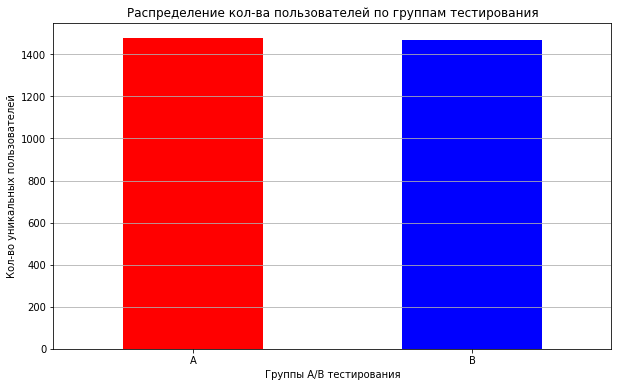

In [22]:
sessions_test_part.groupby('test_group')['user_id'].nunique().plot(
    kind='bar',
    title='Распределение кол-ва пользователей по группам тестирования',
    ylabel='Кол-во уникальных пользователей',
    xlabel='Группы A/B тестирования',
    rot=0,
    color=['red', 'blue'],
    figsize=(10, 6)
)

plt.grid(axis='y')
plt.show()

#### 3.2. Проверка пересечений пользователей

In [23]:
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']
intersection = list(set(group_a) & set(group_b))

if len(intersection) == 0:
    print("Пересечений между группами A и B не обнаружено")
else:
    print("Пользователи в обеих группах:", intersection)

Пересечений между группами A и B не обнаружено


#### 3.3. Равномерность разделения пользователей по устройствам

In [24]:
device_share_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique()
device_share_a = device_share_a / device_share_a.sum()

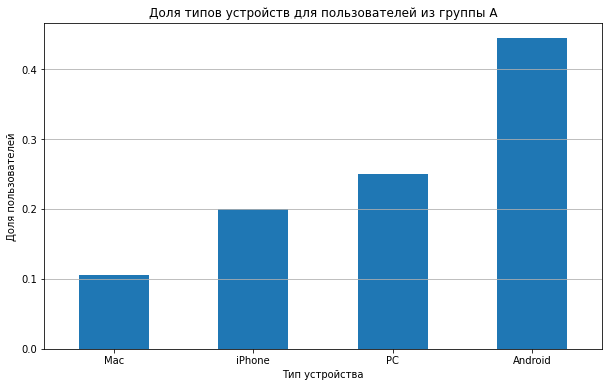

In [25]:
device_share_a.sort_values().plot(
    kind='bar',
    title='Доля типов устройств для пользователей из группы А',
    ylabel='Доля пользователей',
    xlabel='Тип устройства',
    rot=0,
    figsize=(10, 6)
)

plt.grid(axis='y')
plt.show()

In [26]:
device_share_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique()
device_share_b = device_share_b / device_share_b.sum()

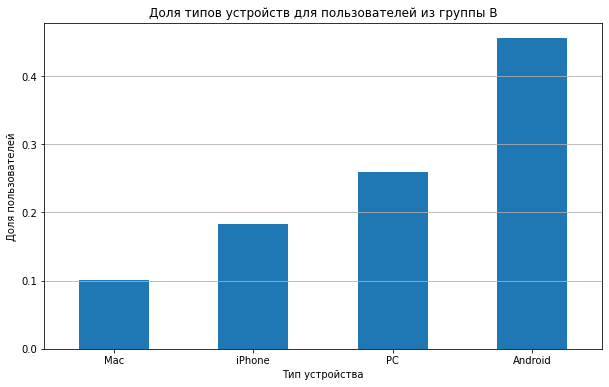

In [27]:
device_share_b.sort_values().plot(
    kind='bar',
    title='Доля типов устройств для пользователей из группы B',
    ylabel='Доля пользователей',
    xlabel='Тип устройства',
    rot=0,
    figsize=(10, 6)
)

plt.grid(axis='y')
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам

In [28]:
region_share_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique()
region_share_a = region_share_a / region_share_a.sum()

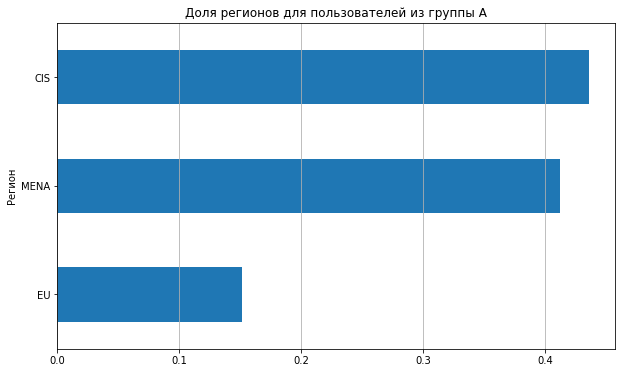

In [29]:
region_share_a.sort_values().plot(
    kind='barh',
    title='Доля регионов для пользователей из группы А',
    ylabel='Доля пользователей',
    xlabel='Регион',
    rot=0,
    figsize=(10, 6)
)

plt.grid(axis='x')
plt.show()

In [30]:
region_share_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique()
region_share_b = region_share_b / region_share_b.sum()

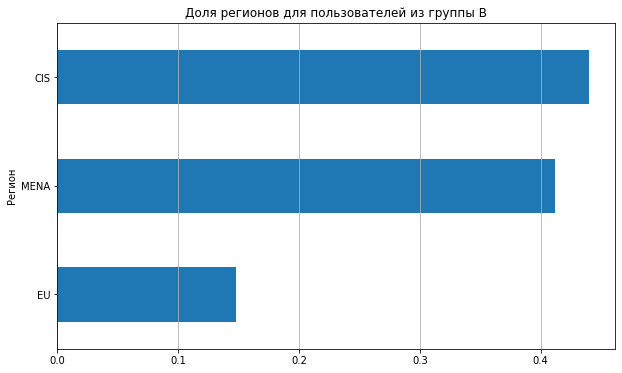

In [31]:
region_share_b.sort_values().plot(
    kind='barh',
    title='Доля регионов для пользователей из группы B',
    ylabel='Доля пользователей',
    xlabel='Регион',
    rot=0,
    figsize=(10, 6)
)

plt.grid(axis='x')
plt.show()

### 3.5. Выводы по проверке разбиения на группы (первый день теста)

1. **Размер групп:** в группе A 1477 уникальных пользователей, в группе B 1466; разница 0,74%.
2. **Пересечения:** пользователей, попавших в обе группы, нет.
3. **Устройства:** структура близка: Android около 44–46%, PC 25–26%, iPhone 18–20%, Mac около 10%; различия в пределах 1–2 п.п.
4. **Регионы:** распределение по регионам в группах визуально совпадает.

Разбиение выглядит корректным, явных нарушений не видно. Статистическая проверка равенства структуры групп не проводилась.

### 4. Проверка результатов A/B-теста

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [32]:
sessions_test = pd.read_csv('data/sessions_project_test.csv')
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [33]:
sessions_test['good_session'] = sessions_test['page_counter'] >= 4

In [34]:
print(sessions_test['good_session'].value_counts())

False    68698
True     31307
Name: good_session, dtype: int64


### 4.2. Метрики и гипотезы

**Метрики:**
- целевая: доля успешных первых сессий (4 и более просмотренных страниц);
- дополнительно стоило бы отслеживать время в приложении за сессию и технические метрики (скорость загрузки ленты, ошибки), но в данных их нет.

**Гипотезы:**
- $H_0$: доля успешных первых сессий в группах A и B одинакова ($p_A = p_B$);
- $H_1$: в группе B доля выше ($p_A < p_B$).

#### 4.3. Сравнение доли успешных первых сессий

In [35]:
first_sessions = sessions_test[sessions_test['session_number'] == 1]

In [36]:
share_a = first_sessions[first_sessions['test_group'] == 'A']['good_session'].mean()
share_b = first_sessions[first_sessions['test_group'] == 'B']['good_session'].mean()

In [37]:
diff_relative = (share_b - share_a) / share_a * 100

In [38]:
diff_absolute = share_b - share_a

In [39]:
print(f"Доля успешных первых сессий в группе A: {share_a:.2%}")
print(f"Доля успешных первых сессий в группе B: {share_b:.2%}")
print(f"Абсолютный прирост (B - A): {diff_absolute * 100:+.2f}%")
print(f"Относительный прирост (B относительно A): {diff_relative:+.2f}%")

Доля успешных первых сессий в группе A: 31.57%
Доля успешных первых сессий в группе B: 31.47%
Абсолютный прирост (B - A): -0.11%
Относительный прирост (B относительно A): -0.33%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

In [40]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Отбираем первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

# 2. Размеры выборок (n_a, n_b)
n_a = int(first_sessions[first_sessions['test_group'] == 'A'].shape[0])
n_b = int(first_sessions[first_sessions['test_group'] == 'B'].shape[0])

# 3. Число успешных сессий (m_a, m_b)
m_a = int(first_sessions[(first_sessions['test_group'] == 'A') & (first_sessions['good_session'] == 1)].shape[0])
m_b = int(first_sessions[(first_sessions['test_group'] == 'B') & (first_sessions['good_session'] == 1)].shape[0])

# 4. Доли
p_a, p_b = m_a / n_a, m_b / n_b

# 5. Проверка предпосылки
if (p_a * n_a > 10) and ((1 - p_a) * n_a > 10) and (p_b * n_b > 10) and ((1 - p_b) * n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')

# 6. Z-тест
alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b], 
    [n_a, n_b], 
    alternative='smaller')

print(f'pvalue = {p_value_ztest:.4f}')

# 7. Вывод
if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение (различий нет)!')
    text_interpretation = 'статистически не изменилась'
else:
    print('Отвергаем H0!')
    text_interpretation = 'статистически значимо изменилась'

print(f'При внедрении нового алгоритма рекомендаций доля успешных первых сессий у пользователей {text_interpretation}.')

Предпосылка о достаточном количестве данных выполняется!
pvalue = 0.5784
Нулевая гипотеза находит подтверждение (различий нет)!
При внедрении нового алгоритма рекомендаций доля успешных первых сессий у пользователей статистически не изменилась.


### 4.5. Выводы по результатам A/B-теста

**Параметры теста:**
- тест шёл с 14 октября по 2 ноября 2025 года (20 дней), это больше расчётного минимума в 9 дней и покрывает почти три полных недели;
- по данным первого дня в группах было 1477 и 1466 пользователей. Число первых сессий за весь период теста в ноутбуке не выводилось, поэтому достижение расчётного размера выборки (41 040 на группу) здесь не проверено.

**Результат:**
- доля успешных первых сессий: A — 31,57%, B — 31,47%; разница −0,11 п.п. (−0,33% относительно A);
- односторонний z-тест для долей: p-value = 0,578 > 0,05, оснований отвергнуть $H_0$ нет.

**Рекомендация:** раскатывать новый алгоритм на всех пользователей не стоит: рост вовлечённости не обнаружен, метрика в группе B даже немного ниже. Алгоритм стоит доработать и протестировать повторно.